В этом ноутбуке будет проверятся гипотезы связанные с обучением модели для классификации картинок. Будет использоваться архитектура ResNet18 c 9 выходными каналами, веса которой будут инициализорваны случайными числами. Датасет для обучения представляет собой 330 картинок, включающий набор изы 9 классов, т. е. из 9 фруктов.

1. Гипотеза: Модель, обученная на цветных фотографиях будет лучше классифицировать картинки, чем на черно-белых.

2. Гипотеза: Модель, обученная на датасете, для которого в процессе обучения случайно выбирается одна из аугмеетаций будет лучше классифицировать картинки.

В качестве лосса будет использоваться кросс-энтропия.

Сначала разобъем датасет на цветную и черно-белые версии.

In [ ]:
# ============ ЦВЕТНОЙ ДАТАСЕТ (color) ============
!pip install kagglehub
import kagglehub, shutil, os
from PIL import Image

path = kagglehub.dataset_download("shreyapmaher/fruits-dataset-images")

if os.path.exists('/content/fruits-dataset-color'):
    shutil.rmtree('/content/fruits-dataset-color')

shutil.copytree(path, '/content/fruits-dataset-color')
print("Цветной датасет загружен в /content/fruits-dataset-color")

# ============ ЧЕРНО-БЕЛЫЙ ДАТАСЕТ (как у тебя в коде - fruits-dataset) ============
if os.path.exists('/content/fruits-dataset'):
    shutil.rmtree('/content/fruits-dataset')

shutil.copytree(path, '/content/fruits-dataset')

for root, _, files in os.walk('/content/fruits-dataset'):
    for file in files:
        if file.endswith(('.jpg','.png','.jpeg')):
            img_path = os.path.join(root, file)
            img = Image.open(img_path).convert('L')
            img.save(img_path)
print("Черно-белый датасет загружен в /content/fruits-dataset")


print("Цветной: /content/fruits-dataset-color")
print("Черно-белый: /content/fruits-dataset")

Using Colab cache for faster access to the 'fruits-dataset-images' dataset.
Цветной датасет загружен в /content/fruits-dataset-color
Черно-белый датасет загружен в /content/fruits-dataset

Готово:
Цветной: /content/fruits-dataset-color
Черно-белый: /content/fruits-dataset


Разобъем два имеющихся датасета на валидационную и тренировочную выборки. Причем в валидационные и тренировочные выборки цветного и черно-белого датасетов попадают одни и те же фотографии.

In [5]:
import os, shutil
from sklearn.model_selection import train_test_split

# ============ ДЛЯ ЦВЕТНОГО ДАТАСЕТА ============
src_color = '/content/fruits-dataset-color/images'
train_color_dir = '/content/train_color'
val_color_dir = '/content/val_color'

os.makedirs(train_color_dir, exist_ok=True)
os.makedirs(val_color_dir, exist_ok=True)

data_color = []
for fruit in os.listdir(src_color):
    fruit_path = os.path.join(src_color, fruit)
    if os.path.isdir(fruit_path):
        for img in os.listdir(fruit_path):
            if img.endswith(('.jpg','.png','.jpeg')):
                data_color.append([os.path.join(fruit_path, img), fruit])

train_color, val_color = train_test_split(data_color, test_size=0.2, random_state=42)

for img_path, fruit in train_color:
    os.makedirs(os.path.join(train_color_dir, fruit), exist_ok=True)
    shutil.copy(img_path, os.path.join(train_color_dir, fruit, os.path.basename(img_path)))

for img_path, fruit in val_color:
    os.makedirs(os.path.join(val_color_dir, fruit), exist_ok=True)
    shutil.copy(img_path, os.path.join(val_color_dir, fruit, os.path.basename(img_path)))

print(f"Цветной датасет - Train: {len(train_color)} images, Val: {len(val_color)} images")

# ============ ДЛЯ ЧЕРНО-БЕЛОГО ДАТАСЕТА ============
src_gray = '/content/fruits-dataset/images'
train_gray_dir = '/content/train'
val_gray_dir = '/content/val'

os.makedirs(train_gray_dir, exist_ok=True)
os.makedirs(val_gray_dir, exist_ok=True)

data_gray = []
for fruit in os.listdir(src_gray):
    fruit_path = os.path.join(src_gray, fruit)
    if os.path.isdir(fruit_path):
        for img in os.listdir(fruit_path):
            if img.endswith(('.jpg','.png','.jpeg')):
                data_gray.append([os.path.join(fruit_path, img), fruit])

train_gray, val_gray = train_test_split(data_gray, test_size=0.2, random_state=42)

for img_path, fruit in train_gray:
    os.makedirs(os.path.join(train_gray_dir, fruit), exist_ok=True)
    shutil.copy(img_path, os.path.join(train_gray_dir, fruit, os.path.basename(img_path)))

for img_path, fruit in val_gray:
    os.makedirs(os.path.join(val_gray_dir, fruit), exist_ok=True)
    shutil.copy(img_path, os.path.join(val_gray_dir, fruit, os.path.basename(img_path)))

print(f"Черно-белый датасет - Train: {len(train_gray)} images, Val: {len(val_gray)} images")


print(f"Цветной трейн: {train_color_dir}")
print(f"Цветной валидация: {val_color_dir}")
print(f"Черно-белый трейн: {train_gray_dir}")
print(f"Черно-белый валидация: {val_gray_dir}")

Цветной датасет - Train: 280 images, Val: 71 images
Черно-белый датасет - Train: 280 images, Val: 71 images
Цветной трейн: /content/train_color
Цветной валидация: /content/val_color
Черно-белый трейн: /content/train
Черно-белый валидация: /content/val


In [ ]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import os
import random

fruit_folder = "/content/fruits-dataset"  #  путь к датасету

images = []
for root, dirs, files in os.walk(fruit_folder):
    for f in files:
        if f.endswith(('.jpg','.png','.jpeg')):
            images.append(os.path.join(root, f))
    if len(images) >= 10:
        break

random.shuffle(images)
images = images[:10]


for img_path in images:
    img = Image.open(img_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0)

    with torch.no_grad():
        pred = model(input_tensor).argmax().item()

    plt.figure()
    plt.imshow(img)
    plt.title(f"{os.path.basename(img_path)}\nПредсказанный класс: {pred}")
    plt.axis('off')
    plt.show()
    print(f"{img_path} -> класс {pred}")

NameError: name 'transform' is not defined

Train samples: 280
Val samples: 71

=== ДО ОБУЧЕНИЯ ===
Train Loss: 2.4275, Train Acc: 11.07%
Val Loss: 3.3767, Val Acc: 9.86%


Epoch 1/10: 100%|██████████| 9/9 [00:10<00:00,  1.14s/it, loss=1.13]


Epoch 1: Train Loss=1.2839, Train Acc=59.29%, Val Loss=11.1937, Val Acc=39.44%


Epoch 2/10: 100%|██████████| 9/9 [00:09<00:00,  1.07s/it, loss=0.689]


Epoch 2: Train Loss=0.8100, Train Acc=73.21%, Val Loss=4.3821, Val Acc=53.52%


...

Epoch 8: Train Loss=0.4013, Train Acc=87.14%, Val Loss=2.5945, Val Acc=57.75%


Epoch 9/10: 100%|██████████| 9/9 [00:09<00:00,  1.03s/it, loss=0.209]


Epoch 9: Train Loss=0.3036, Train Acc=90.00%, Val Loss=4.6070, Val Acc=52.11%


Epoch 10/10: 100%|██████████| 9/9 [00:08<00:00,  1.01it/s, loss=0.875]


Epoch 10: Train Loss=0.3445, Train Acc=90.36%, Val Loss=6.3692, Val Acc=36.62%


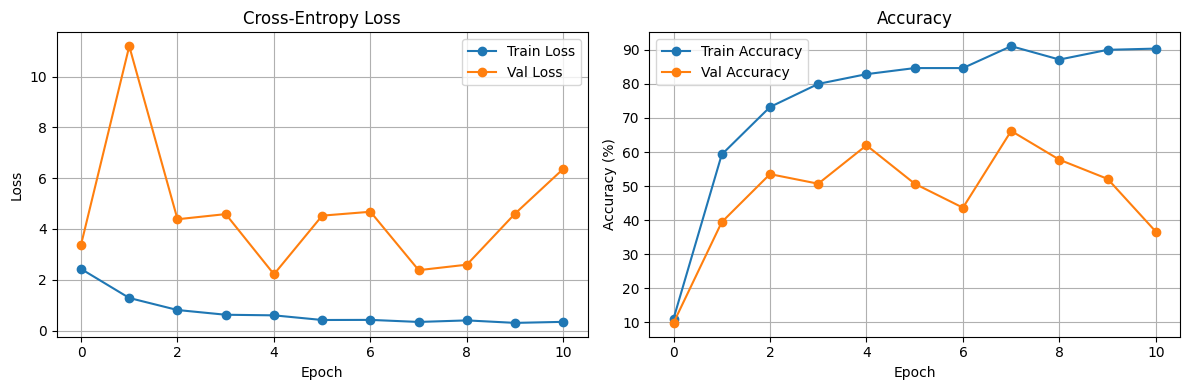

Модель сохранена

Классы: ['apple fruit', 'banana fruit', 'cherry fruit', 'chickoo fruit', 'grapes fruit', 'kiwi fruit', 'mango fruit', 'orange fruit', 'strawberry fruit']


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
from PIL import Image
import os
import random
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# ============ ГИПЕРПАРАМЕТРЫ ============
BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 10
# ========================================

fruits = ['apple fruit', 'banana fruit', 'cherry fruit', 'chickoo fruit',
          'grapes fruit', 'kiwi fruit', 'mango fruit', 'orange fruit', 'strawberry fruit']

train_paths, train_labels = [], []
val_paths, val_labels = [], []

for fruit in fruits:
    label = fruits.index(fruit)

    train_folder = f'/content/train/{fruit}'
    if os.path.exists(train_folder):
        for img in os.listdir(train_folder):
            if img.endswith(('.jpg','.png','.jpeg')):
                train_paths.append(os.path.join(train_folder, img))
                train_labels.append(label)

    val_folder = f'/content/val/{fruit}'
    if os.path.exists(val_folder):
        for img in os.listdir(val_folder):
            if img.endswith(('.jpg','.png','.jpeg')):
                val_paths.append(os.path.join(val_folder, img))
                val_labels.append(label)

 
train_transform = transforms.Compose([                                              # аугментация для трейна
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(35),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor()
])


val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

def get_batch(paths, labels, start, batch_size, transform):
    end = min(start + batch_size, len(paths))
    imgs = []
    for i in range(start, end):
        img = Image.open(paths[i]).convert('RGB')
        imgs.append(transform(img))
    return torch.stack(imgs), torch.tensor(labels[start:end])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(512, len(fruits))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Train samples: {len(train_paths)}")
print(f"Val samples: {len(val_paths)}")


print("\n=== ДО ОБУЧЕНИЯ ===")
model.eval()
train_loss_before = 0
train_correct_before = 0
val_loss_before = 0
val_correct_before = 0

with torch.no_grad():
    for start in range(0, len(train_paths), BATCH_SIZE):
        x, y = get_batch(train_paths, train_labels, start, BATCH_SIZE, val_transform)
        x, y = x.to(device), y.to(device)
        outputs = model(x)
        loss = criterion(outputs, y)
        train_loss_before += loss.item()
        pred = outputs.argmax(1)
        train_correct_before += (pred == y).sum().item()

    for start in range(0, len(val_paths), BATCH_SIZE):
        x, y = get_batch(val_paths, val_labels, start, BATCH_SIZE, val_transform)
        x, y = x.to(device), y.to(device)
        outputs = model(x)
        loss = criterion(outputs, y)
        val_loss_before += loss.item()
        pred = outputs.argmax(1)
        val_correct_before += (pred == y).sum().item()

avg_train_loss_before = train_loss_before / (len(train_paths) / BATCH_SIZE)
avg_val_loss_before = val_loss_before / (len(val_paths) / BATCH_SIZE)

print(f"Train Loss: {avg_train_loss_before:.4f}, Train Acc: {100*train_correct_before/len(train_paths):.2f}%")
print(f"Val Loss: {avg_val_loss_before:.4f}, Val Acc: {100*val_correct_before/len(val_paths):.2f}%")
print("="*50)

train_losses, val_losses = [avg_train_loss_before], [avg_val_loss_before]
train_accs, val_accs = [100*train_correct_before/len(train_paths)], [100*val_correct_before/len(val_paths)]

# ============ ОБУЧЕНИЕ ============
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    train_correct = 0

    paired = list(zip(train_paths, train_labels))
    random.shuffle(paired)
    train_paths, train_labels = zip(*paired)

    loop = tqdm(range(0, len(train_paths), BATCH_SIZE), desc=f'Epoch {epoch+1}/{EPOCHS}')
    for start in loop:
        x, y = get_batch(train_paths, train_labels, start, BATCH_SIZE, train_transform)
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, pred = torch.max(outputs, 1)
        train_correct += (pred == y).sum().item()
        loop.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / (len(train_paths) / BATCH_SIZE)
    train_acc = 100 * train_correct / len(train_paths)
    train_losses.append(avg_train_loss)
    train_accs.append(train_acc)

    model.eval()
    val_loss = 0
    val_correct = 0

    with torch.no_grad():
        for start in range(0, len(val_paths), BATCH_SIZE):
            x, y = get_batch(val_paths, val_labels, start, BATCH_SIZE, val_transform)
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            val_loss += loss.item()
            _, pred = torch.max(outputs, 1)
            val_correct += (pred == y).sum().item()

    avg_val_loss = val_loss / (len(val_paths) / BATCH_SIZE)
    val_acc = 100 * val_correct / len(val_paths)
    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)

    print(f'Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Train Acc={train_acc:.2f}%, Val Loss={avg_val_loss:.4f}, Val Acc={val_acc:.2f}%')


plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(range(0, EPOCHS+1), train_losses, marker='o', label='Train Loss')
plt.plot(range(0, EPOCHS+1), val_losses, marker='o', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Cross-Entropy Loss')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(range(0, EPOCHS+1), train_accs, marker='o', label='Train Accuracy')
plt.plot(range(0, EPOCHS+1), val_accs, marker='o', label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

torch.save(model.state_dict(), '/content/model.pth')
print('Модель сохранена')
print(f"\nКлассы: {fruits}")

Train samples: 280
Val samples: 71

=== ДО ОБУЧЕНИЯ ===
Train Loss: 2.5152, Train Acc: 10.00%
Val Loss: 3.0613, Val Acc: 15.49%


Epoch 1/10: 100%|██████████| 9/9 [00:09<00:00,  1.05s/it, loss=0.78]


Epoch 1: Train Loss=1.1068, Train Acc=64.29%, Val Loss=10.5356, Val Acc=22.54%


Epoch 2/10: 100%|██████████| 9/9 [00:09<00:00,  1.07s/it, loss=2.02]


Epoch 2: Train Loss=0.7644, Train Acc=78.93%, Val Loss=6.7037, Val Acc=46.48%


...

Epoch 8: Train Loss=0.2989, Train Acc=91.07%, Val Loss=2.6954, Val Acc=59.15%


Epoch 9/10: 100%|██████████| 9/9 [00:09<00:00,  1.05s/it, loss=0.179]


Epoch 9: Train Loss=0.2312, Train Acc=93.21%, Val Loss=1.8795, Val Acc=71.83%


Epoch 10/10: 100%|██████████| 9/9 [00:09<00:00,  1.05s/it, loss=0.328]


Epoch 10: Train Loss=0.2355, Train Acc=92.50%, Val Loss=2.8673, Val Acc=59.15%


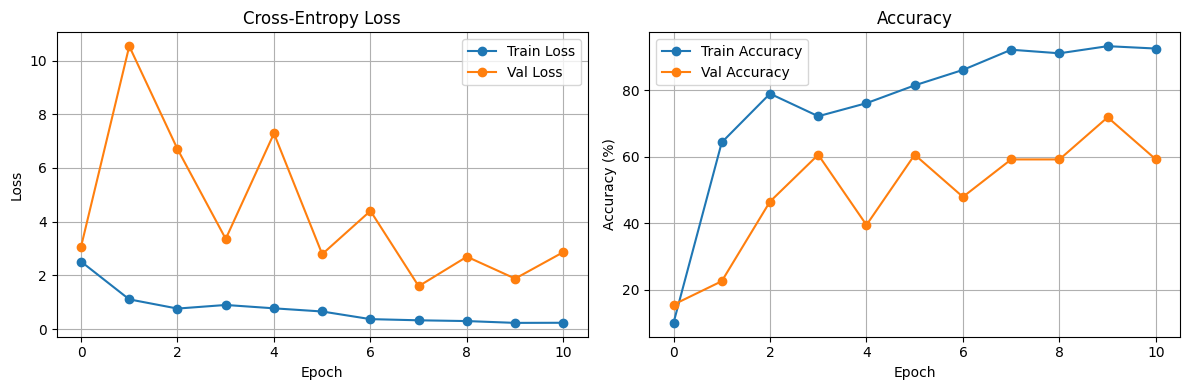

Модель сохранена

Классы: ['apple fruit', 'banana fruit', 'cherry fruit', 'chickoo fruit', 'grapes fruit', 'kiwi fruit', 'mango fruit', 'orange fruit', 'strawberry fruit']


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
from PIL import Image
import os
import random
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# ============ ГИПЕРПАРАМЕТРЫ ============
BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 10
# ========================================

fruits = ['apple fruit', 'banana fruit', 'cherry fruit', 'chickoo fruit',
          'grapes fruit', 'kiwi fruit', 'mango fruit', 'orange fruit', 'strawberry fruit']

train_paths, train_labels = [], []
val_paths, val_labels = [], []

for fruit in fruits:
    label = fruits.index(fruit)

    train_folder = f'/content/train/{fruit}'
    if os.path.exists(train_folder):
        for img in os.listdir(train_folder):
            if img.endswith(('.jpg','.png','.jpeg')):
                train_paths.append(os.path.join(train_folder, img))
                train_labels.append(label)

    val_folder = f'/content/val/{fruit}'
    if os.path.exists(val_folder):
        for img in os.listdir(val_folder):
            if img.endswith(('.jpg','.png','.jpeg')):
                val_paths.append(os.path.join(val_folder, img))
                val_labels.append(label)


train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(35),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor()
])


val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

def get_batch(paths, labels, start, batch_size, transform):
    end = min(start + batch_size, len(paths))
    imgs = []
    for i in range(start, end):
        img = Image.open(paths[i]).convert('RGB')
        imgs.append(transform(img))
    return torch.stack(imgs), torch.tensor(labels[start:end])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(512, len(fruits))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Train samples: {len(train_paths)}")
print(f"Val samples: {len(val_paths)}")


print("\n=== ДО ОБУЧЕНИЯ ===")
model.eval()
train_loss_before = 0
train_correct_before = 0
val_loss_before = 0
val_correct_before = 0

with torch.no_grad():
    for start in range(0, len(train_paths), BATCH_SIZE):
        x, y = get_batch(train_paths, train_labels, start, BATCH_SIZE, val_transform)
        x, y = x.to(device), y.to(device)
        outputs = model(x)
        loss = criterion(outputs, y)
        train_loss_before += loss.item()
        pred = outputs.argmax(1)
        train_correct_before += (pred == y).sum().item()

    for start in range(0, len(val_paths), BATCH_SIZE):
        x, y = get_batch(val_paths, val_labels, start, BATCH_SIZE, val_transform)
        x, y = x.to(device), y.to(device)
        outputs = model(x)
        loss = criterion(outputs, y)
        val_loss_before += loss.item()
        pred = outputs.argmax(1)
        val_correct_before += (pred == y).sum().item()

avg_train_loss_before = train_loss_before / (len(train_paths) / BATCH_SIZE)
avg_val_loss_before = val_loss_before / (len(val_paths) / BATCH_SIZE)

print(f"Train Loss: {avg_train_loss_before:.4f}, Train Acc: {100*train_correct_before/len(train_paths):.2f}%")
print(f"Val Loss: {avg_val_loss_before:.4f}, Val Acc: {100*val_correct_before/len(val_paths):.2f}%")
print("="*50)

train_losses, val_losses = [avg_train_loss_before], [avg_val_loss_before]
train_accs, val_accs = [100*train_correct_before/len(train_paths)], [100*val_correct_before/len(val_paths)]

# ============ ОБУЧЕНИЕ ============
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    train_correct = 0

    paired = list(zip(train_paths, train_labels))
    random.shuffle(paired)
    train_paths, train_labels = zip(*paired)

    loop = tqdm(range(0, len(train_paths), BATCH_SIZE), desc=f'Epoch {epoch+1}/{EPOCHS}')
    for start in loop:
        x, y = get_batch(train_paths, train_labels, start, BATCH_SIZE, train_transform)
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, pred = torch.max(outputs, 1)
        train_correct += (pred == y).sum().item()
        loop.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / (len(train_paths) / BATCH_SIZE)
    train_acc = 100 * train_correct / len(train_paths)
    train_losses.append(avg_train_loss)
    train_accs.append(train_acc)

    model.eval()
    val_loss = 0
    val_correct = 0

    with torch.no_grad():
        for start in range(0, len(val_paths), BATCH_SIZE):
            x, y = get_batch(val_paths, val_labels, start, BATCH_SIZE, val_transform)
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            val_loss += loss.item()
            _, pred = torch.max(outputs, 1)
            val_correct += (pred == y).sum().item()

    avg_val_loss = val_loss / (len(val_paths) / BATCH_SIZE)
    val_acc = 100 * val_correct / len(val_paths)
    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)

    print(f'Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Train Acc={train_acc:.2f}%, Val Loss={avg_val_loss:.4f}, Val Acc={val_acc:.2f}%')


plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(range(0, EPOCHS+1), train_losses, marker='o', label='Train Loss')
plt.plot(range(0, EPOCHS+1), val_losses, marker='o', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Cross-Entropy Loss')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(range(0, EPOCHS+1), train_accs, marker='o', label='Train Accuracy')
plt.plot(range(0, EPOCHS+1), val_accs, marker='o', label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

torch.save(model.state_dict(), '/content/model.pth')
print('Модель сохранена')
print(f"\nКлассы: {fruits}")

Для проведения статистического сравнения моделей, отличающихся форматом выборок, на которых они были обучены проведем в трех ячейках ниже Fine-tune ResNet18

1-ая модель обучается на цветном датасете
2-ая на черно-белом аугментированном случайно в каждой эпохе датасете
3-я на черно-белом


ИТЕРАЦИЯ 1/30
Epoch 1: Train Loss=2.2571, Train Acc=21.43%, Val Loss=7.9658, Val Acc=7.04%
Epoch 2: Train Loss=1.8142, Train Acc=37.86%, Val Loss=9.4444, Val Acc=12.68%
Epoch 3: Train Loss=1.5087, Train Acc=49.29%, Val Loss=9.6891, Val Acc=11.27%
Epoch 4: Train Loss=1.2041, Train Acc=64.29%, Val Loss=7.9875, Val Acc=21.13%
Epoch 5: Train Loss=1.0423, Train Acc=67.86%, Val Loss=7.8049, Val Acc=15.49%
Epoch 6: Train Loss=0.8808, Train Acc=71.79%, Val Loss=3.9465, Val Acc=26.76%
Epoch 7: Train Loss=0.7902, Train Acc=76.07%, Val Loss=3.6385, Val Acc=36.62%
Epoch 8: Train Loss=0.5370, Train Acc=86.43%, Val Loss=2.5492, Val Acc=46.48%
Epoch 9: Train Loss=0.3136, Train Acc=92.14%, Val Loss=3.2089, Val Acc=32.39%
Epoch 10: Train Loss=0.1510, Train Acc=98.21%, Val Loss=2.9112, Val Acc=30.99%

ИТЕРАЦИЯ 2/30
Epoch 1: Train Loss=2.1671, Train Acc=24.29%, Val Loss=12.8987, Val Acc=9.86%
Epoch 2: Train Loss=1.8012, Train Acc=39.64%, Val Loss=10.0640, Val Acc=12.68%
Epoch 3: Train Loss=1.4241, Train

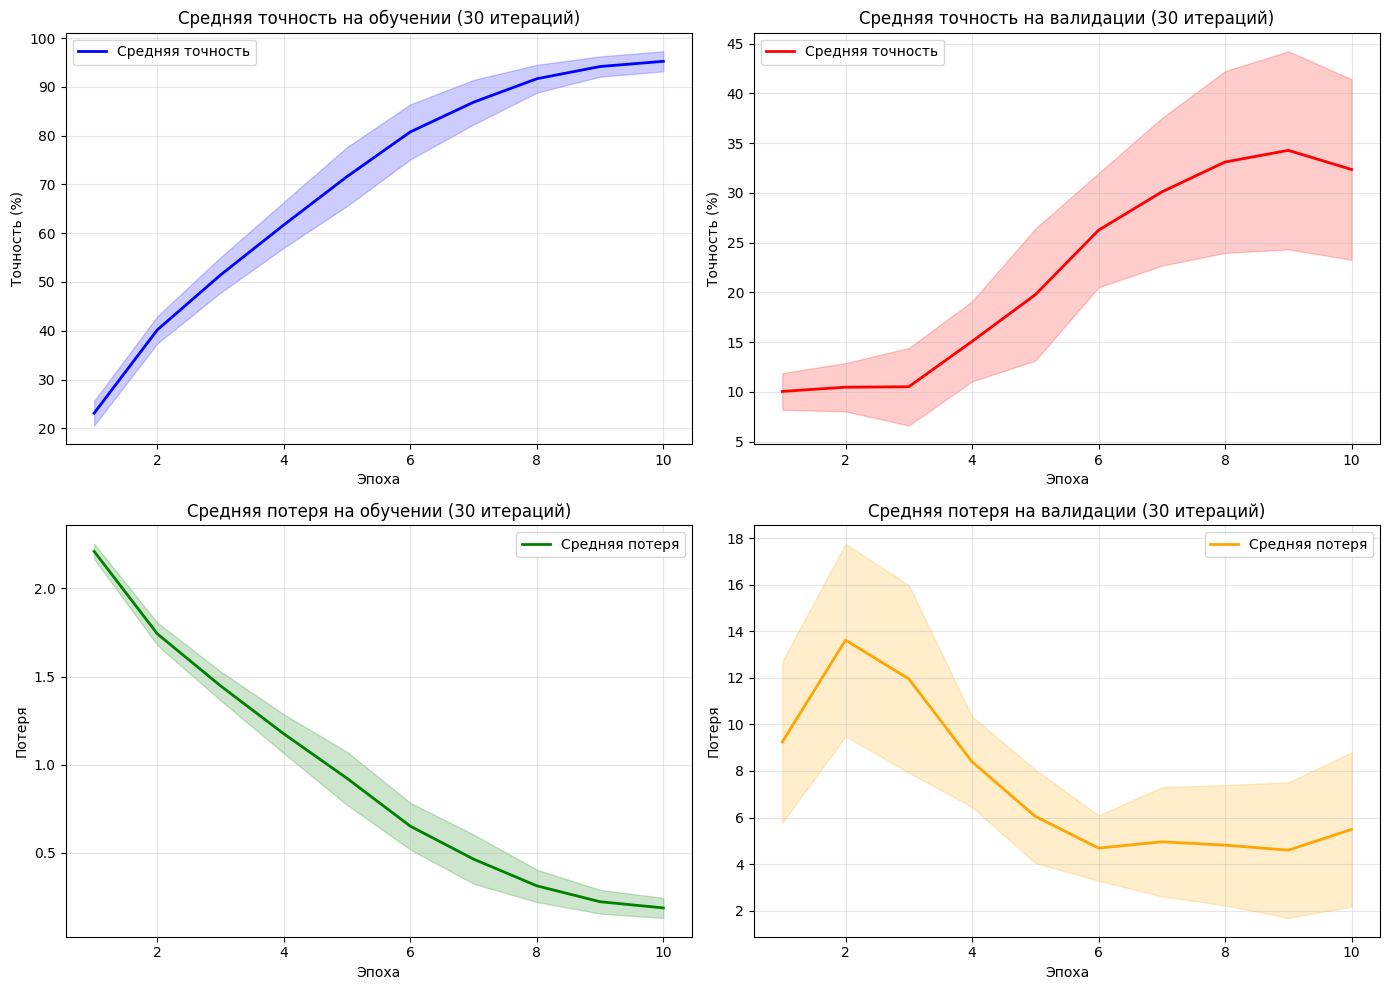

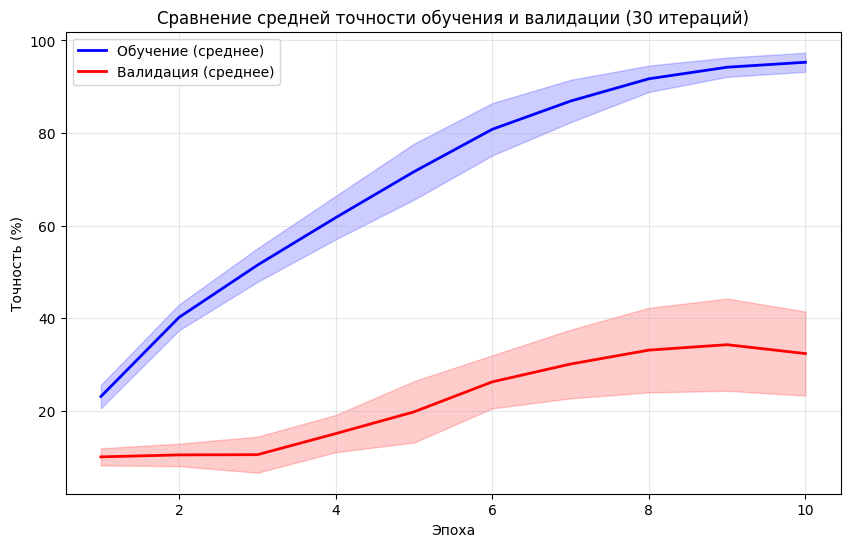


Статистика по итерациям:
Разброс финальной точности на валидации: от 11.27% до 52.11%
Медианная точность на валидации: 33.80%


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
from PIL import Image
import os
import random
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# ============ ГИПЕРПАРАМЕТРЫ ============
BATCH_SIZE = 32
LEARNING_RATE = 0.0005
EPOCHS = 10
# ========================================

# ============ КЛАССЫ ФРУКТОВ ============
fruits = ['apple fruit', 'banana fruit', 'cherry fruit', 'chickoo fruit',
          'grapes fruit', 'kiwi fruit', 'mango fruit', 'orange fruit', 'strawberry fruit']
# ========================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


all_iterations_results = {
    'train_acc': [],
    'val_acc': [],
    'train_loss': [],
    'val_loss': []
}

for iteration in range(30):                       # 30 итераций обучения стоковой модели с рандомными весами и 9 выходами
    print(f"\n{'='*60}")
    print(f"ИТЕРАЦИЯ {iteration+1}/30")
    print(f"{'='*60}")

    model = models.resnet18(pretrained=False)
    model.fc = nn.Linear(512, len(fruits))
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    train_paths, train_labels = [], []
    val_paths, val_labels = [], []

    for fruit in fruits:
        label = fruits.index(fruit)

        train_folder = f'/content/train/{fruit}'
        if os.path.exists(train_folder):
            for img in os.listdir(train_folder):
                if img.endswith(('.jpg','.png','.jpeg')):
                    train_paths.append(os.path.join(train_folder, img))
                    train_labels.append(label)

        val_folder = f'/content/val/{fruit}'
        if os.path.exists(val_folder):
            for img in os.listdir(val_folder):
                if img.endswith(('.jpg','.png','.jpeg')):
                    val_paths.append(os.path.join(val_folder, img))
                    val_labels.append(label)

    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor()
    ])

    def get_batch(paths, labels, start, batch_size):
        end = min(start + batch_size, len(paths))
        imgs = []
        for i in range(start, end):
            img = Image.open(paths[i]).convert('RGB')
            imgs.append(transform(img))
        return torch.stack(imgs), torch.tensor(labels[start:end])

    iter_train_losses = []
    iter_val_losses = []
    iter_train_accs = []
    iter_val_accs = []

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0
        train_correct = 0

        paired = list(zip(train_paths, train_labels))
        random.shuffle(paired)
        train_paths_shuffled, train_labels_shuffled = zip(*paired)

        for start in range(0, len(train_paths), BATCH_SIZE):
            x, y = get_batch(train_paths_shuffled, train_labels_shuffled, start, BATCH_SIZE)
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, pred = torch.max(outputs, 1)
            train_correct += (pred == y).sum().item()

        avg_train_loss = train_loss / (len(train_paths) / BATCH_SIZE)
        train_acc = 100 * train_correct / len(train_paths)

        model.eval()
        val_loss = 0
        val_correct = 0

        with torch.no_grad():
            for start in range(0, len(val_paths), BATCH_SIZE):
                x, y = get_batch(val_paths, val_labels, start, BATCH_SIZE)
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                loss = criterion(outputs, y)
                val_loss += loss.item()
                _, pred = torch.max(outputs, 1)
                val_correct += (pred == y).sum().item()

        avg_val_loss = val_loss / (len(val_paths) / BATCH_SIZE)
        val_acc = 100 * val_correct / len(val_paths)

        iter_train_losses.append(avg_train_loss)
        iter_val_losses.append(avg_val_loss)
        iter_train_accs.append(train_acc)
        iter_val_accs.append(val_acc)

        print(f'Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Train Acc={train_acc:.2f}%, Val Loss={avg_val_loss:.4f}, Val Acc={val_acc:.2f}%')

    all_iterations_results['train_acc'].append(iter_train_accs)
    all_iterations_results['val_acc'].append(iter_val_accs)
    all_iterations_results['train_loss'].append(iter_train_losses)
    all_iterations_results['val_loss'].append(iter_val_losses)


train_acc_array = np.array(all_iterations_results['train_acc'])
val_acc_array = np.array(all_iterations_results['val_acc'])
train_loss_array = np.array(all_iterations_results['train_loss'])
val_loss_array = np.array(all_iterations_results['val_loss'])

mean_train_acc = np.mean(train_acc_array, axis=0)
std_train_acc = np.std(train_acc_array, axis=0)
mean_val_acc = np.mean(val_acc_array, axis=0)
std_val_acc = np.std(val_acc_array, axis=0)

mean_train_loss = np.mean(train_loss_array, axis=0)
std_train_loss = np.std(train_loss_array, axis=0)
mean_val_loss = np.mean(val_loss_array, axis=0)
std_val_loss = np.std(val_loss_array, axis=0)

print(f"\n{'='*60}")
print("ИТОГОВАЯ СТАТИСТИКА ПО 30 ИТЕРАЦИЯМ")
print(f"{'='*60}")
print(f"Финальная средняя точность на обучении: {mean_train_acc[-1]:.2f}% (±{std_train_acc[-1]:.2f})")
print(f"Финальная средняя точность на валидации: {mean_val_acc[-1]:.2f}% (±{std_val_acc[-1]:.2f})")
print(f"Финальная средняя потеря на обучении: {mean_train_loss[-1]:.4f} (±{std_train_loss[-1]:.4f})")
print(f"Финальная средняя потеря на валидации: {mean_val_loss[-1]:.4f} (±{std_val_loss[-1]:.4f})")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(range(1, EPOCHS+1), mean_train_acc, 'b-', linewidth=2, label='Средняя точность')
axes[0, 0].fill_between(range(1, EPOCHS+1), mean_train_acc - std_train_acc, mean_train_acc + std_train_acc, alpha=0.2, color='b')
axes[0, 0].set_xlabel('Эпоха')
axes[0, 0].set_ylabel('Точность (%)')
axes[0, 0].set_title('Средняя точность на обучении (30 итераций)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(range(1, EPOCHS+1), mean_val_acc, 'r-', linewidth=2, label='Средняя точность')
axes[0, 1].fill_between(range(1, EPOCHS+1), mean_val_acc - std_val_acc, mean_val_acc + std_val_acc, alpha=0.2, color='r')
axes[0, 1].set_xlabel('Эпоха')
axes[0, 1].set_ylabel('Точность (%)')
axes[0, 1].set_title('Средняя точность на валидации (30 итераций)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(range(1, EPOCHS+1), mean_train_loss, 'g-', linewidth=2, label='Средняя потеря')
axes[1, 0].fill_between(range(1, EPOCHS+1), mean_train_loss - std_train_loss, mean_train_loss + std_train_loss, alpha=0.2, color='g')
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('Потеря')
axes[1, 0].set_title('Средняя потеря на обучении (30 итераций)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(range(1, EPOCHS+1), mean_val_loss, 'orange', linewidth=2, label='Средняя потеря')
axes[1, 1].fill_between(range(1, EPOCHS+1), mean_val_loss - std_val_loss, mean_val_loss + std_val_loss, alpha=0.2, color='orange')
axes[1, 1].set_xlabel('Эпоха')
axes[1, 1].set_ylabel('Потеря')
axes[1, 1].set_title('Средняя потеря на валидации (30 итераций)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS+1), mean_train_acc, 'b-', linewidth=2, label='Обучение (среднее)')
plt.plot(range(1, EPOCHS+1), mean_val_acc, 'r-', linewidth=2, label='Валидация (среднее)')
plt.fill_between(range(1, EPOCHS+1), mean_train_acc - std_train_acc, mean_train_acc + std_train_acc, alpha=0.2, color='b')
plt.fill_between(range(1, EPOCHS+1), mean_val_acc - std_val_acc, mean_val_acc + std_val_acc, alpha=0.2, color='r')
plt.xlabel('Эпоха')
plt.ylabel('Точность (%)')
plt.title('Сравнение средней точности обучения и валидации (30 итераций)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nСтатистика по итерациям:")
print(f"Разброс финальной точности на валидации: от {np.min(val_acc_array[:, -1]):.2f}% до {np.max(val_acc_array[:, -1]):.2f}%")
print(f"Медианная точность на валидации: {np.median(val_acc_array[:, -1]):.2f}%")


ИТЕРАЦИЯ 1/30
Epoch 1: Train Loss=2.2493, Train Acc=22.14%, Val Loss=7.6895, Val Acc=7.04%
Epoch 2: Train Loss=2.0985, Train Acc=31.79%, Val Loss=11.4955, Val Acc=7.04%
Epoch 3: Train Loss=1.8580, Train Acc=33.93%, Val Loss=9.1946, Val Acc=12.68%
Epoch 4: Train Loss=1.7638, Train Acc=35.00%, Val Loss=6.3658, Val Acc=14.08%
Epoch 5: Train Loss=1.7651, Train Acc=35.71%, Val Loss=4.1103, Val Acc=21.13%
Epoch 6: Train Loss=1.6619, Train Acc=41.43%, Val Loss=2.6722, Val Acc=35.21%
Epoch 7: Train Loss=1.5017, Train Acc=47.14%, Val Loss=4.9491, Val Acc=22.54%
Epoch 8: Train Loss=1.5527, Train Acc=43.93%, Val Loss=2.9211, Val Acc=22.54%
Epoch 9: Train Loss=1.3864, Train Acc=52.14%, Val Loss=2.4810, Val Acc=38.03%
Epoch 10: Train Loss=1.3553, Train Acc=52.86%, Val Loss=3.2713, Val Acc=29.58%

ИТЕРАЦИЯ 2/30
Epoch 1: Train Loss=2.2645, Train Acc=18.93%, Val Loss=7.0648, Val Acc=9.86%
Epoch 2: Train Loss=2.1004, Train Acc=28.21%, Val Loss=20.1040, Val Acc=12.68%
Epoch 3: Train Loss=1.7954, Train 

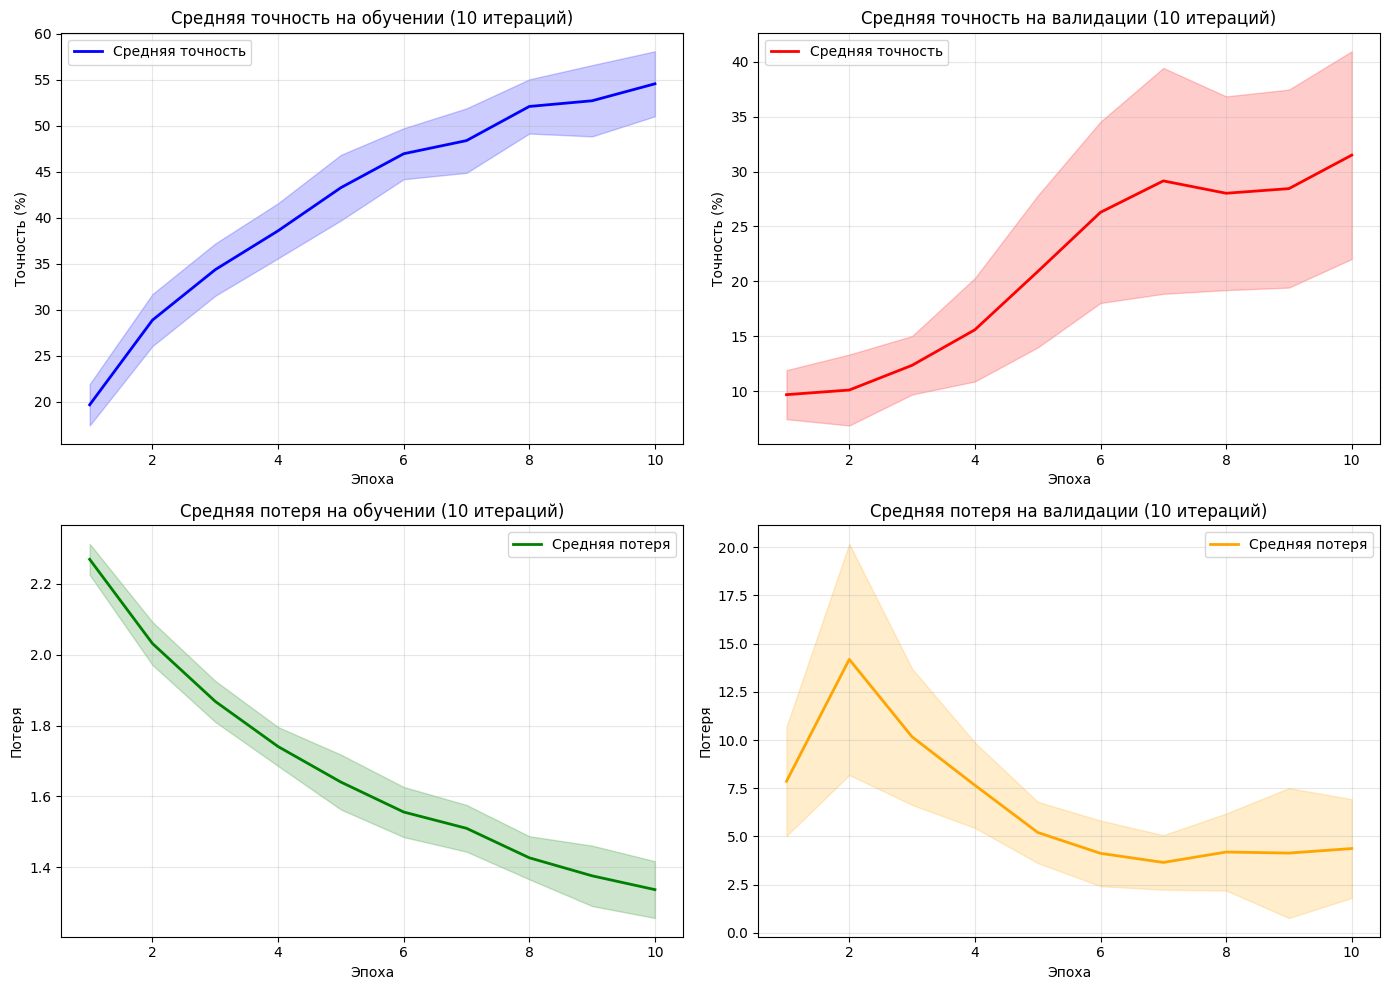

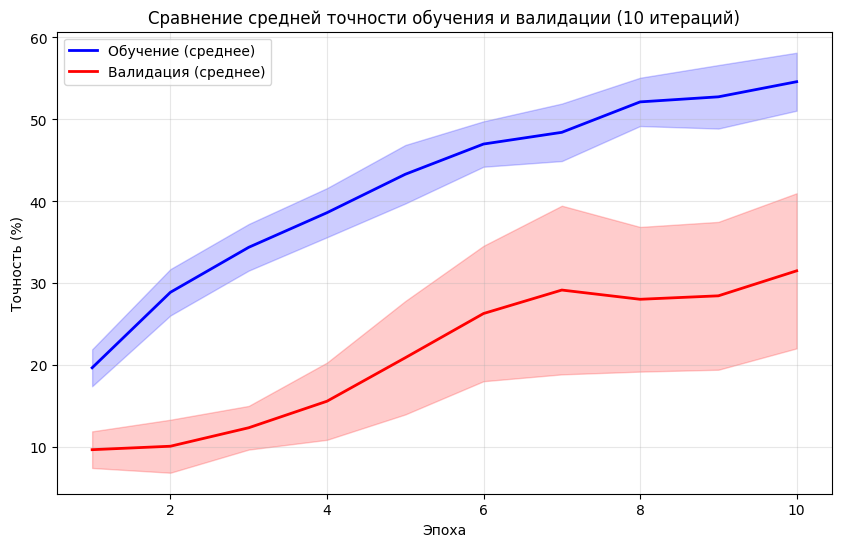


Статистика по итерациям:
Разброс финальной точности на валидации: от 11.27% до 52.11%
Медианная точность на валидации: 29.58%


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
from PIL import Image
import os
import random
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# ============ ГИПЕРПАРАМЕТРЫ ============
BATCH_SIZE = 32
LEARNING_RATE = 0.0005
EPOCHS = 10
# ========================================

fruits = ['apple fruit', 'banana fruit', 'cherry fruit', 'chickoo fruit',
          'grapes fruit', 'kiwi fruit', 'mango fruit', 'orange fruit', 'strawberry fruit']


train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(35),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor()
])


val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

def get_batch(paths, labels, start, batch_size, transform):
    end = min(start + batch_size, len(paths))
    imgs = []
    for i in range(start, end):
        img = Image.open(paths[i]).convert('RGB')
        imgs.append(transform(img))
    return torch.stack(imgs), torch.tensor(labels[start:end])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


all_iterations_results = {        
    'train_acc': [],
    'val_acc': [],
    'train_loss': [],
    'val_loss': []
}

for iteration in range(30):                # 30 итераций обучения стоковой модели с рандомными весами и 9 выходами
    print(f"\n{'='*60}")
    print(f"ИТЕРАЦИЯ {iteration+1}/30")
    print(f"{'='*60}")

    # Создаем новую модель с нуля
    model = models.resnet18(pretrained=False)
    model.fc = nn.Linear(512, len(fruits))
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

  
    train_paths, train_labels = [], []
    val_paths, val_labels = [], []

    for fruit in fruits:
        label = fruits.index(fruit)

        train_folder = f'/content/train/{fruit}'
        if os.path.exists(train_folder):
            for img in os.listdir(train_folder):
                if img.endswith(('.jpg','.png','.jpeg')):
                    train_paths.append(os.path.join(train_folder, img))
                    train_labels.append(label)

        val_folder = f'/content/val/{fruit}'
        if os.path.exists(val_folder):
            for img in os.listdir(val_folder):
                if img.endswith(('.jpg','.png','.jpeg')):
                    val_paths.append(os.path.join(val_folder, img))
                    val_labels.append(label)


    iter_train_losses = []
    iter_val_losses = []
    iter_train_accs = []
    iter_val_accs = []


    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0
        train_correct = 0

        paired = list(zip(train_paths, train_labels))
        random.shuffle(paired)
        train_paths_shuffled, train_labels_shuffled = zip(*paired)

        for start in range(0, len(train_paths), BATCH_SIZE):
            x, y = get_batch(train_paths_shuffled, train_labels_shuffled, start, BATCH_SIZE, train_transform)
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, pred = torch.max(outputs, 1)
            train_correct += (pred == y).sum().item()

        avg_train_loss = train_loss / (len(train_paths) / BATCH_SIZE)
        train_acc = 100 * train_correct / len(train_paths)

      
        model.eval()
        val_loss = 0
        val_correct = 0

        with torch.no_grad():
            for start in range(0, len(val_paths), BATCH_SIZE):
                x, y = get_batch(val_paths, val_labels, start, BATCH_SIZE, val_transform)
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                loss = criterion(outputs, y)
                val_loss += loss.item()
                _, pred = torch.max(outputs, 1)
                val_correct += (pred == y).sum().item()

        avg_val_loss = val_loss / (len(val_paths) / BATCH_SIZE)
        val_acc = 100 * val_correct / len(val_paths)

        iter_train_losses.append(avg_train_loss)
        iter_val_losses.append(avg_val_loss)
        iter_train_accs.append(train_acc)
        iter_val_accs.append(val_acc)

        print(f'Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Train Acc={train_acc:.2f}%, Val Loss={avg_val_loss:.4f}, Val Acc={val_acc:.2f}%')


    all_iterations_results['train_acc'].append(iter_train_accs)
    all_iterations_results['val_acc'].append(iter_val_accs)
    all_iterations_results['train_loss'].append(iter_train_losses)
    all_iterations_results['val_loss'].append(iter_val_losses)


train_acc_array = np.array(all_iterations_results['train_acc'])
val_acc_array = np.array(all_iterations_results['val_acc'])
train_loss_array = np.array(all_iterations_results['train_loss'])
val_loss_array = np.array(all_iterations_results['val_loss'])


mean_train_acc = np.mean(train_acc_array, axis=0)
std_train_acc = np.std(train_acc_array, axis=0)
mean_val_acc = np.mean(val_acc_array, axis=0)
std_val_acc = np.std(val_acc_array, axis=0)

mean_train_loss = np.mean(train_loss_array, axis=0)
std_train_loss = np.std(train_loss_array, axis=0)
mean_val_loss = np.mean(val_loss_array, axis=0)
std_val_loss = np.std(val_loss_array, axis=0)

print(f"\n{'='*60}")
print("ИТОГОВАЯ СТАТИСТИКА ПО 10 ИТЕРАЦИЯМ")
print(f"{'='*60}")
print(f"Финальная средняя точность на обучении: {mean_train_acc[-1]:.2f}% (±{std_train_acc[-1]:.2f})")
print(f"Финальная средняя точность на валидации: {mean_val_acc[-1]:.2f}% (±{std_val_acc[-1]:.2f})")
print(f"Финальная средняя потеря на обучении: {mean_train_loss[-1]:.4f} (±{std_train_loss[-1]:.4f})")
print(f"Финальная средняя потеря на валидации: {mean_val_loss[-1]:.4f} (±{std_val_loss[-1]:.4f})")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(range(1, EPOCHS+1), mean_train_acc, 'b-', linewidth=2, label='Средняя точность')
axes[0, 0].fill_between(range(1, EPOCHS+1), mean_train_acc - std_train_acc, mean_train_acc + std_train_acc, alpha=0.2, color='b')
axes[0, 0].set_xlabel('Эпоха')
axes[0, 0].set_ylabel('Точность (%)')
axes[0, 0].set_title('Средняя точность на обучении (10 итераций)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(range(1, EPOCHS+1), mean_val_acc, 'r-', linewidth=2, label='Средняя точность')
axes[0, 1].fill_between(range(1, EPOCHS+1), mean_val_acc - std_val_acc, mean_val_acc + std_val_acc, alpha=0.2, color='r')
axes[0, 1].set_xlabel('Эпоха')
axes[0, 1].set_ylabel('Точность (%)')
axes[0, 1].set_title('Средняя точность на валидации (10 итераций)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(range(1, EPOCHS+1), mean_train_loss, 'g-', linewidth=2, label='Средняя потеря')
axes[1, 0].fill_between(range(1, EPOCHS+1), mean_train_loss - std_train_loss, mean_train_loss + std_train_loss, alpha=0.2, color='g')
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('Потеря')
axes[1, 0].set_title('Средняя потеря на обучении (10 итераций)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(range(1, EPOCHS+1), mean_val_loss, 'orange', linewidth=2, label='Средняя потеря')
axes[1, 1].fill_between(range(1, EPOCHS+1), mean_val_loss - std_val_loss, mean_val_loss + std_val_loss, alpha=0.2, color='orange')
axes[1, 1].set_xlabel('Эпоха')
axes[1, 1].set_ylabel('Потеря')
axes[1, 1].set_title('Средняя потеря на валидации (10 итераций)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS+1), mean_train_acc, 'b-', linewidth=2, label='Обучение (среднее)')
plt.plot(range(1, EPOCHS+1), mean_val_acc, 'r-', linewidth=2, label='Валидация (среднее)')
plt.fill_between(range(1, EPOCHS+1), mean_train_acc - std_train_acc, mean_train_acc + std_train_acc, alpha=0.2, color='b')
plt.fill_between(range(1, EPOCHS+1), mean_val_acc - std_val_acc, mean_val_acc + std_val_acc, alpha=0.2, color='r')
plt.xlabel('Эпоха')
plt.ylabel('Точность (%)')
plt.title('Сравнение средней точности обучения и валидации (10 итераций)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nСтатистика по итерациям:")
print(f"Разброс финальной точности на валидации: от {np.min(val_acc_array[:, -1]):.2f}% до {np.max(val_acc_array[:, -1]):.2f}%")
print(f"Медианная точность на валидации: {np.median(val_acc_array[:, -1]):.2f}%")


ЦВЕТНОЙ ДАТАСЕТ - ИТЕРАЦИЯ 1/30
Epoch 1: Train Loss=2.0255, Train Acc=23.57%, Val Loss=3.7502, Val Acc=25.35%
Epoch 2: Train Loss=1.4004, Train Acc=55.71%, Val Loss=7.5053, Val Acc=11.27%
Epoch 3: Train Loss=1.2109, Train Acc=59.29%, Val Loss=5.3056, Val Acc=21.13%
Epoch 4: Train Loss=1.1428, Train Acc=63.93%, Val Loss=4.7793, Val Acc=19.72%
Epoch 5: Train Loss=1.0329, Train Acc=64.64%, Val Loss=3.2956, Val Acc=43.66%
Epoch 6: Train Loss=0.7729, Train Acc=72.50%, Val Loss=2.0618, Val Acc=53.52%
Epoch 7: Train Loss=0.7024, Train Acc=78.93%, Val Loss=1.7886, Val Acc=60.56%
Epoch 8: Train Loss=0.9097, Train Acc=71.07%, Val Loss=7.1047, Val Acc=43.66%
Epoch 9: Train Loss=0.8437, Train Acc=71.79%, Val Loss=3.3968, Val Acc=45.07%
Epoch 10: Train Loss=0.7540, Train Acc=75.00%, Val Loss=1.6758, Val Acc=54.93%

ЦВЕТНОЙ ДАТАСЕТ - ИТЕРАЦИЯ 2/30
Epoch 1: Train Loss=1.9087, Train Acc=34.64%, Val Loss=4.4199, Val Acc=9.86%
Epoch 2: Train Loss=1.5183, Train Acc=52.14%, Val Loss=5.8893, Val Acc=11.27

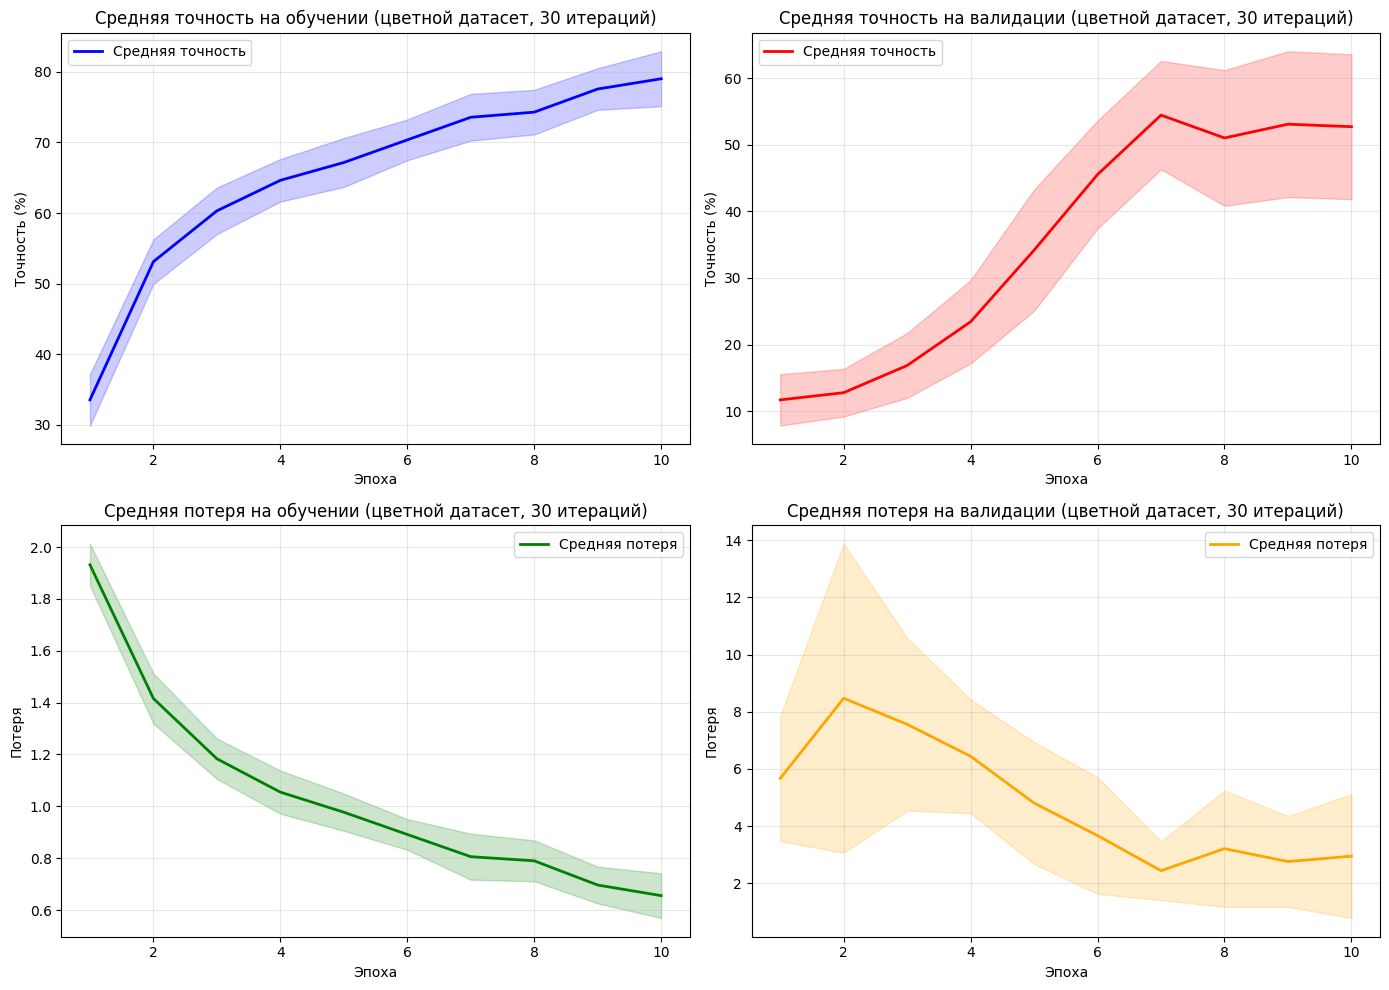

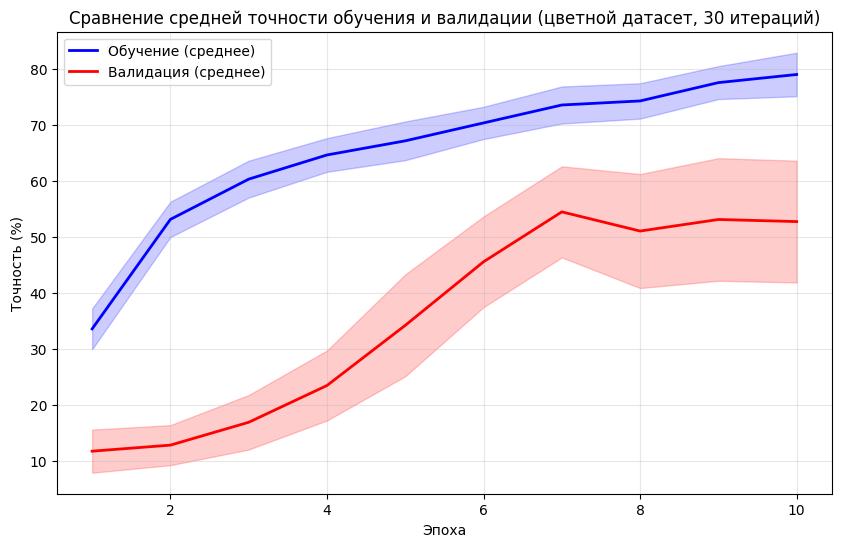


Статистика по итерациям (цветной датасет):
Разброс финальной точности на валидации: от 16.90% до 67.61%
Медианная точность на валидации: 54.23%


In [ ]:
# ============ ОБУЧЕНИЕ НА ЦВЕТНОМ ДАТАСЕТЕ ============
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
from PIL import Image
import os
import random
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# ============ ГИПЕРПАРАМЕТРЫ ============
BATCH_SIZE = 32
LEARNING_RATE = 0.0005
EPOCHS = 10
# ========================================

# ============ КЛАССЫ ФРУКТОВ ============
fruits = ['apple fruit', 'banana fruit', 'cherry fruit', 'chickoo fruit',
          'grapes fruit', 'kiwi fruit', 'mango fruit', 'orange fruit', 'strawberry fruit']
#

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Запуск 30 итераций обучения на ЦВЕТНОМ датасете
all_iterations_results_color = {
    'train_acc': [],
    'val_acc': [],
    'train_loss': [],
    'val_loss': []
}

for iteration in range(30):                 # 30 итераций обучения стоковой модели с рандомными весами и 9 выходами
    print(f"\n{'='*60}")
    print(f"ЦВЕТНОЙ ДАТАСЕТ - ИТЕРАЦИЯ {iteration+1}/30")
    print(f"{'='*60}")

    model = models.resnet18(pretrained=False)
    model.fc = nn.Linear(512, len(fruits))
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    train_paths, train_labels = [], []
    val_paths, val_labels = [], []

    # Используем пути для цветного датасета
    train_folder_base = '/content/train_color'
    val_folder_base = '/content/val_color'

    for fruit in fruits:
        label = fruits.index(fruit)

        train_folder = f'{train_folder_base}/{fruit}'
        if os.path.exists(train_folder):
            for img in os.listdir(train_folder):
                if img.endswith(('.jpg','.png','.jpeg')):
                    train_paths.append(os.path.join(train_folder, img))
                    train_labels.append(label)

        val_folder = f'{val_folder_base}/{fruit}'
        if os.path.exists(val_folder):
            for img in os.listdir(val_folder):
                if img.endswith(('.jpg','.png','.jpeg')):
                    val_paths.append(os.path.join(val_folder, img))
                    val_labels.append(label)

    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor()
    ])

    def get_batch(paths, labels, start, batch_size):
        end = min(start + batch_size, len(paths))
        imgs = []
        for i in range(start, end):
            img = Image.open(paths[i]).convert('RGB')
            imgs.append(transform(img))
        return torch.stack(imgs), torch.tensor(labels[start:end])

    iter_train_losses = []
    iter_val_losses = []
    iter_train_accs = []
    iter_val_accs = []

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0
        train_correct = 0

        paired = list(zip(train_paths, train_labels))
        random.shuffle(paired)
        train_paths_shuffled, train_labels_shuffled = zip(*paired)

        for start in range(0, len(train_paths), BATCH_SIZE):
            x, y = get_batch(train_paths_shuffled, train_labels_shuffled, start, BATCH_SIZE)
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, pred = torch.max(outputs, 1)
            train_correct += (pred == y).sum().item()

        avg_train_loss = train_loss / (len(train_paths) / BATCH_SIZE)
        train_acc = 100 * train_correct / len(train_paths)

        model.eval()
        val_loss = 0
        val_correct = 0

        with torch.no_grad():
            for start in range(0, len(val_paths), BATCH_SIZE):
                x, y = get_batch(val_paths, val_labels, start, BATCH_SIZE)
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                loss = criterion(outputs, y)
                val_loss += loss.item()
                _, pred = torch.max(outputs, 1)
                val_correct += (pred == y).sum().item()

        avg_val_loss = val_loss / (len(val_paths) / BATCH_SIZE)
        val_acc = 100 * val_correct / len(val_paths)

        iter_train_losses.append(avg_train_loss)
        iter_val_losses.append(avg_val_loss)
        iter_train_accs.append(train_acc)
        iter_val_accs.append(val_acc)

        print(f'Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Train Acc={train_acc:.2f}%, Val Loss={avg_val_loss:.4f}, Val Acc={val_acc:.2f}%')

    all_iterations_results_color['train_acc'].append(iter_train_accs)
    all_iterations_results_color['val_acc'].append(iter_val_accs)
    all_iterations_results_color['train_loss'].append(iter_train_losses)
    all_iterations_results_color['val_loss'].append(iter_val_losses)


train_acc_array_color = np.array(all_iterations_results_color['train_acc'])
val_acc_array_color = np.array(all_iterations_results_color['val_acc'])
train_loss_array_color = np.array(all_iterations_results_color['train_loss'])
val_loss_array_color = np.array(all_iterations_results_color['val_loss'])


mean_train_acc_color = np.mean(train_acc_array_color, axis=0)
std_train_acc_color = np.std(train_acc_array_color, axis=0)
mean_val_acc_color = np.mean(val_acc_array_color, axis=0)
std_val_acc_color = np.std(val_acc_array_color, axis=0)

mean_train_loss_color = np.mean(train_loss_array_color, axis=0)
std_train_loss_color = np.std(train_loss_array_color, axis=0)
mean_val_loss_color = np.mean(val_loss_array_color, axis=0)
std_val_loss_color = np.std(val_loss_array_color, axis=0)

print(f"\n{'='*60}")
print("ИТОГОВАЯ СТАТИСТИКА ПО 30 ИТЕРАЦИЯМ (ЦВЕТНОЙ ДАТАСЕТ)")
print(f"{'='*60}")
print(f"Финальная средняя точность на обучении: {mean_train_acc_color[-1]:.2f}% (±{std_train_acc_color[-1]:.2f})")
print(f"Финальная средняя точность на валидации: {mean_val_acc_color[-1]:.2f}% (±{std_val_acc_color[-1]:.2f})")
print(f"Финальная средняя потеря на обучении: {mean_train_loss_color[-1]:.4f} (±{std_train_loss_color[-1]:.4f})")
print(f"Финальная средняя потеря на валидации: {mean_val_loss_color[-1]:.4f} (±{std_val_loss_color[-1]:.4f})")


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(range(1, EPOCHS+1), mean_train_acc_color, 'b-', linewidth=2, label='Средняя точность')
axes[0, 0].fill_between(range(1, EPOCHS+1), mean_train_acc_color - std_train_acc_color, mean_train_acc_color + std_train_acc_color, alpha=0.2, color='b')
axes[0, 0].set_xlabel('Эпоха')
axes[0, 0].set_ylabel('Точность (%)')
axes[0, 0].set_title('Средняя точность на обучении (цветной датасет, 30 итераций)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(range(1, EPOCHS+1), mean_val_acc_color, 'r-', linewidth=2, label='Средняя точность')
axes[0, 1].fill_between(range(1, EPOCHS+1), mean_val_acc_color - std_val_acc_color, mean_val_acc_color + std_val_acc_color, alpha=0.2, color='r')
axes[0, 1].set_xlabel('Эпоха')
axes[0, 1].set_ylabel('Точность (%)')
axes[0, 1].set_title('Средняя точность на валидации (цветной датасет, 30 итераций)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(range(1, EPOCHS+1), mean_train_loss_color, 'g-', linewidth=2, label='Средняя потеря')
axes[1, 0].fill_between(range(1, EPOCHS+1), mean_train_loss_color - std_train_loss_color, mean_train_loss_color + std_train_loss_color, alpha=0.2, color='g')
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('Потеря')
axes[1, 0].set_title('Средняя потеря на обучении (цветной датасет, 30 итераций)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(range(1, EPOCHS+1), mean_val_loss_color, 'orange', linewidth=2, label='Средняя потеря')
axes[1, 1].fill_between(range(1, EPOCHS+1), mean_val_loss_color - std_val_loss_color, mean_val_loss_color + std_val_loss_color, alpha=0.2, color='orange')
axes[1, 1].set_xlabel('Эпоха')
axes[1, 1].set_ylabel('Потеря')
axes[1, 1].set_title('Средняя потеря на валидации (цветной датасет, 30 итераций)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS+1), mean_train_acc_color, 'b-', linewidth=2, label='Обучение (среднее)')
plt.plot(range(1, EPOCHS+1), mean_val_acc_color, 'r-', linewidth=2, label='Валидация (среднее)')
plt.fill_between(range(1, EPOCHS+1), mean_train_acc_color - std_train_acc_color, mean_train_acc_color + std_train_acc_color, alpha=0.2, color='b')
plt.fill_between(range(1, EPOCHS+1), mean_val_acc_color - std_val_acc_color, mean_val_acc_color + std_val_acc_color, alpha=0.2, color='r')
plt.xlabel('Эпоха')
plt.ylabel('Точность (%)')
plt.title('Сравнение средней точности обучения и валидации (цветной датасет, 30 итераций)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nСтатистика по итерациям (цветной датасет):")
print(f"Разброс финальной точности на валидации: от {np.min(val_acc_array_color[:, -1]):.2f}% до {np.max(val_acc_array_color[:, -1]):.2f}%")
print(f"Медианная точность на валидации: {np.median(val_acc_array_color[:, -1]):.2f}%")

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import re
from scipy import stats

for filename in ["/content/color.txt", "/content/aug.txt", "/content/without_aug.txt"] :

    filename = "/content/color.txt"  

    # Парсинг
    data = []
    with open(filename, 'r') as f:
        for line in f:
            nums = re.findall(r"[-+]?\d*\.\d+|\d+", line)
            if len(nums) >= 5:
                data.append({
                    'epoch': int(nums[0]),
                    'train_loss': float(nums[1]),
                    'val_loss': float(nums[3])
                })

    df = pd.DataFrame(data)
    epochs = sorted(df['epoch'].unique())


    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    for i, epoch in enumerate(epochs):
        # Train Loss
        ax1 = axes[0, i]
        train_data = df[df['epoch'] == epoch]['train_loss']
        ax1.hist(train_data, bins=8, edgecolor='black', alpha=0.7, color='blue')
        ax1.set_title(f'Epoch {epoch} - Train Loss')
        ax1.set_xlabel('Loss')
        ax1.set_ylabel('Frequency')
        ax1.axvline(train_data.mean(), color='red', linestyle='--', label=f'mean={train_data.mean():.4f}')
        ax1.legend()

        # Val Loss
        ax2 = axes[1, i]
        val_data = df[df['epoch'] == epoch]['val_loss']
        ax2.hist(val_data, bins=8, edgecolor='black', alpha=0.7, color='orange')
        ax2.set_title(f'Epoch {epoch} - Val Loss')
        ax2.set_xlabel('Loss')
        ax2.set_ylabel('Frequency')
        ax2.axvline(val_data.mean(), color='red', linestyle='--', label=f'mean={val_data.mean():.4f}')
        ax2.legend()

    plt.tight_layout()
    plt.show()

   
    print("\n" + "="*80)
    print("ТЕСТ НА НОРМАЛЬНОСТЬ (Shapiro-Wilk)")
    print("="*80)

    for epoch in epochs:
        print(f"\n--- EPOCH {epoch} ---")

        train_data = df[df['epoch'] == epoch]['train_loss']

        stat, p = stats.shapiro(train_data)
        print(f"Train Loss:  p-value = {p:.15f}  {'(нормальное)' if p > 0.05 else '(НЕ нормальное)'}")

        val_data = df[df['epoch'] == epoch]['val_loss']

        stat, p = stats.shapiro(val_data)
        print(f"Val Loss:    p-value = {p:.15f}  {'(нормальное)' if p > 0.05 else '(НЕ нормальное)'}")


Проверим получившееся выборки, состоящие из валидационных и тренировочных лосов на последней 10-ой эпохе на различимость. Для начала проверим имеющиеся данные с последних 3-х эпох одной итерерации на нормальность при помощи критерия Шапиро-Уилко

================================================================================
ТЕСТ НА НОРМАЛЬНОСТЬ (Shapiro-Wilk)
================================================================================

--- EPOCH 8 ---
Train Loss:  p-value = 0.842660290688187  (нормальное)
Val Loss:    p-value = 0.000017870656672  (НЕ нормальное)

--- EPOCH 9 ---
Train Loss:  p-value = 0.960962853277180  (нормальное)
Val Loss:    p-value = 0.000019862273103  (НЕ нормальное)

--- EPOCH 10 ---
Train Loss:  p-value = 0.448645264857788  (нормальное)
Val Loss:    p-value = 0.000000313020312  (НЕ нормальное)

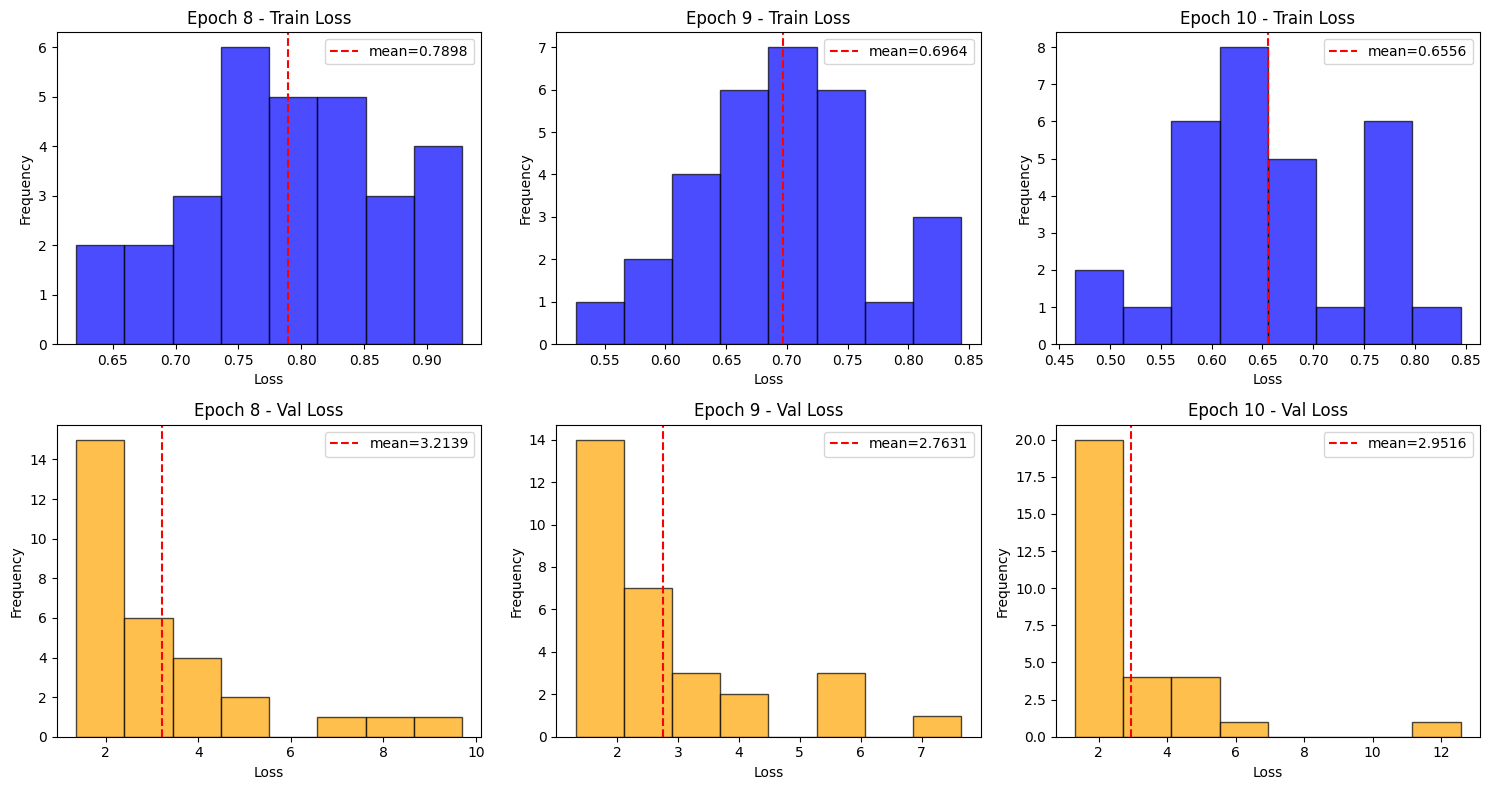

================================================================================
ТЕСТ НА НОРМАЛЬНОСТЬ (Shapiro-Wilk)
================================================================================

--- EPOCH 8 ---
Train Loss:  p-value = 0.842660290688187  (нормальное)
Val Loss:    p-value = 0.000017870656672  (НЕ нормальное)

--- EPOCH 9 ---
Train Loss:  p-value = 0.960962853277180  (нормальное)
Val Loss:    p-value = 0.000019862273103  (НЕ нормальное)

--- EPOCH 10 ---
Train Loss:  p-value = 0.448645264857788  (нормальное)
Val Loss:    p-value = 0.000000313020312  (НЕ нормальное)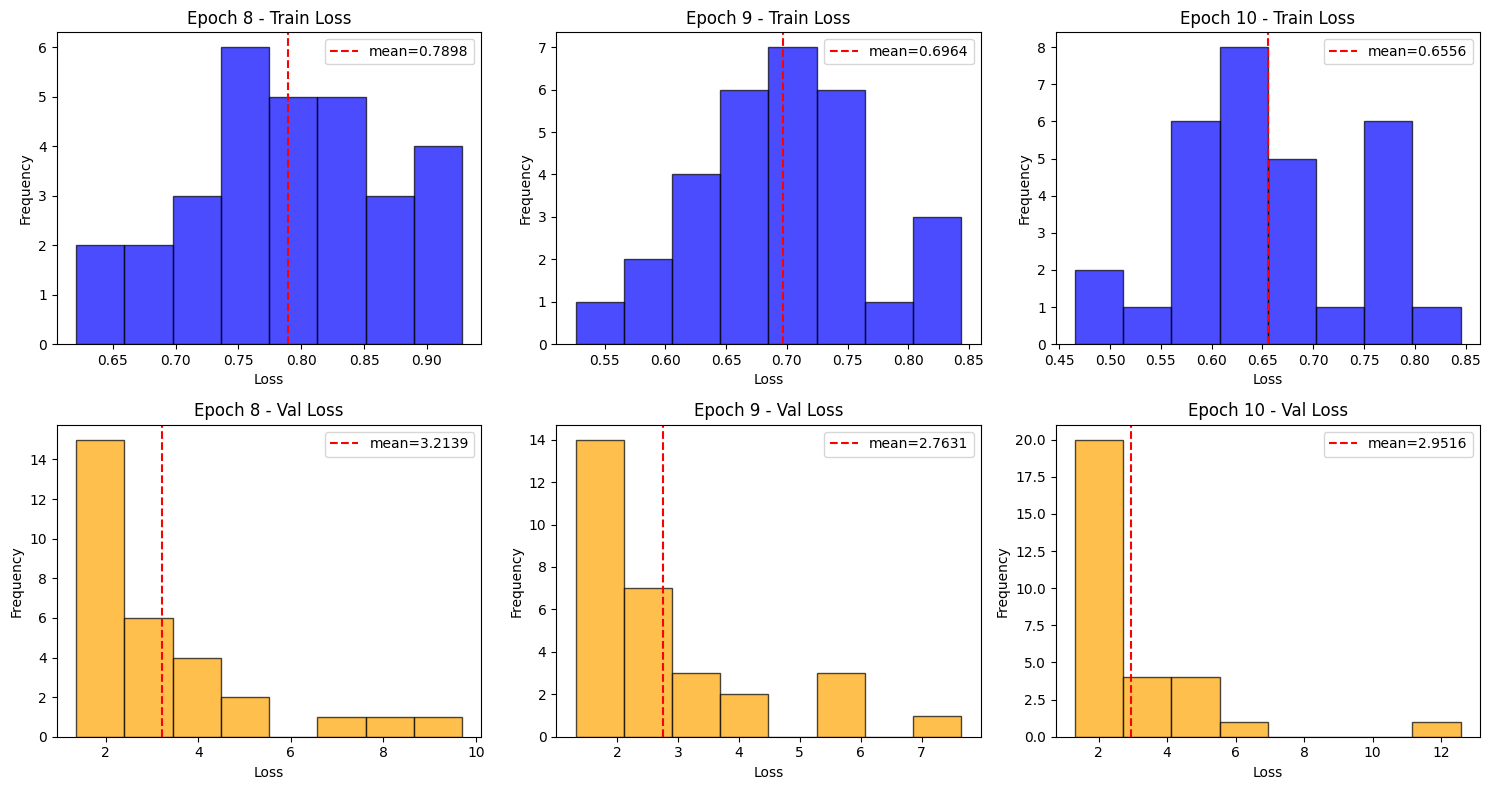

================================================================================
ТЕСТ НА НОРМАЛЬНОСТЬ (Shapiro-Wilk)
================================================================================

--- EPOCH 8 ---
Train Loss:  p-value = 0.842660290688187  (нормальное)
Val Loss:    p-value = 0.000017870656672  (НЕ нормальное)

--- EPOCH 9 ---
Train Loss:  p-value = 0.960962853277180  (нормальное)
Val Loss:    p-value = 0.000019862273103  (НЕ нормальное)

--- EPOCH 10 ---
Train Loss:  p-value = 0.448645264857788  (нормальное)
Val Loss:    p-value = 0.000000313020312  (НЕ нормальное)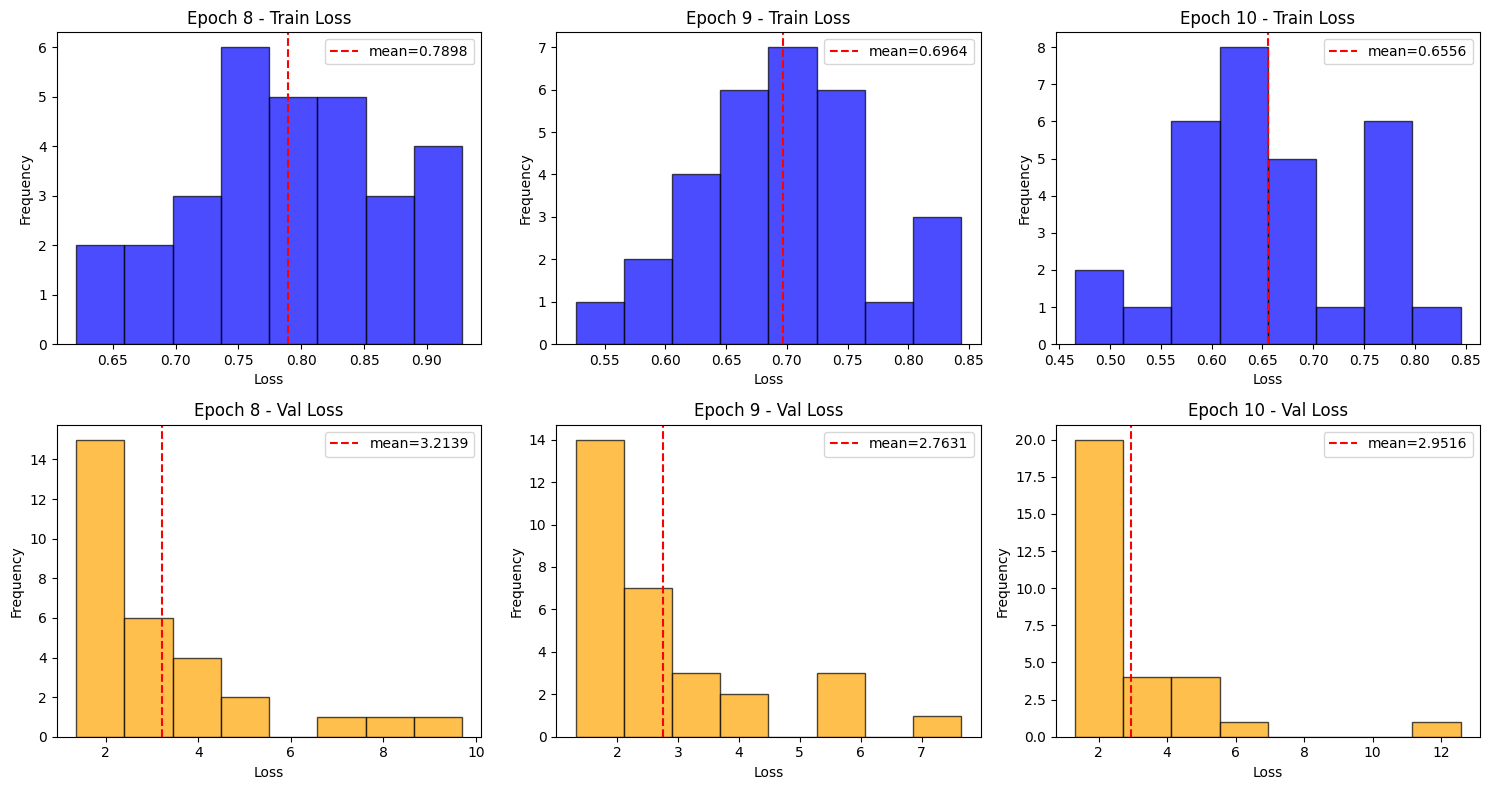

Видно, что тренировочный лосс имеет нормальное распределение, а валидациный - нет на уровнях значимости 0.05. Применим для сравнения первого лосс t-тест, а для валидационных тест Манна-Уитни, в виду нормальности распределения данных из первой и не нормальности данных из второй выборок.

In [ ]:
import pandas as pd
import re
from scipy.stats import ttest_ind, mannwhitneyu
import numpy as np
from itertools import combinations


files = ["/content/color.txt", "/content/aug.txt", "/content/without_aug.txt"]
names = ["Color", "Aug", "Without Aug"]


def parse_metrics(filename, epoch_target=10):
    train_losses = []
    val_losses = []
    with open(filename, 'r') as f:
        for line in f:
            nums = re.findall(r"[-+]?\d*\.\d+|\d+", line)
            if len(nums) >= 5 and int(nums[0]) == epoch_target:
                train_losses.append(float(nums[1]))  # Train Loss
                val_losses.append(float(nums[3]))    # Val Loss
    return train_losses, val_losses

train_data = {}
val_data = {}

for file, name in zip(files, names):
    train_losses, val_losses = parse_metrics(file)
    train_data[name] = train_losses
    val_data[name] = val_losses
    print(f"{name}: Train={len(train_losses)} значений, Val={len(val_losses)} значений")

print("\n" + "="*70)
print("TRAIN LOSS - t-КРИТЕРИЙ СТЬЮДЕНТА (проверяем СРЕДНИЕ)")
print("="*70)

for name1, name2 in combinations(names, 2):
    t_stat, p_value = ttest_ind(train_data[name1], train_data[name2])
    print(f"\n{name1} vs {name2}:")
    print(f"  Среднее: {name1}={np.mean(train_data[name1]):.4f}, {name2}={np.mean(train_data[name2]):.4f}")
    print(f"  p-value = {p_value:.15f}")
    print(f"  Вывод: {'✅ Средние отличаются' if p_value < 0.05 else '❌ Средние не отличаются'}")

print("\n" + "="*70)
print("VAL LOSS - МАННА-УИТНИ (проверяем МЕДИАНЫ)")
print("="*70)

for name1, name2 in combinations(names, 2):
    u_stat, p_value = mannwhitneyu(val_data[name1], val_data[name2])
    print(f"\n{name1} vs {name2}:")
    print(f"  Медиана: {name1}={np.median(val_data[name1]):.4f}, {name2}={np.median(val_data[name2]):.4f}")
    print(f"  p-value = {p_value:.15f}")
    print(f"  Вывод: {'✅ Медианы отличаются' if p_value < 0.05 else '❌ Медианы не отличаются'}")

======================================================================
TRAIN LOSS - t-КРИТЕРИЙ СТЬЮДЕНТА (проверяем СРЕДНИЕ)
======================================================================

Color vs Aug:
  Среднее: Color=0.6556, Aug=1.3372
  p-value = 0.000000000000000
  Вывод: ✅ Средние отличаются

Color vs Without Aug:
  Среднее: Color=0.6556, Without Aug=0.1871
  p-value = 0.000000000000000
  Вывод: ✅ Средние отличаются

Aug vs Without Aug:
  Среднее: Aug=1.3372, Without Aug=0.1871
  p-value = 0.000000000000000
  Вывод: ✅ Средние отличаются

======================================================================
VAL LOSS - МАННА-УИТНИ (проверяем МЕДИАНЫ)
======================================================================

Color vs Aug:
  Медиана: Color=2.1351, Aug=3.5283
  p-value = 0.000471375144213
  Вывод: ✅ Медианы отличаются

Color vs Without Aug:
  Медиана: Color=2.1351, Without Aug=4.4016
  p-value = 0.000010906865251
  Вывод: ✅ Медианы отличаются

Aug vs Without Aug:
  Медиана: Aug=3.5283, Without Aug=4.4016
  p-value = 0.070126594071288
  Вывод: ❌ Медианы не отличаются

Проанализируем полученные результаты. Лосс на трейне ниже у цветной модели, Но при этом модель, обученная на цветных картинках тратит в 1.5 раза больше времени на fine-tune. В то же время следующая модель, обученная без аугментации имеет показатели хуже, чем у предыдущей. А самое плохое качество у аугментированной модели.

Статитстика, извлеченная из данных валидационной выборки показывает, что нет статистического различия между аугментированной и неаугментированной моделью черно-белых датасетов. Пи-значение при их сравнении составляет 0.05, что очень близко к пороговому значению сравнения 

Попробуем проверить гипотезу, что черно-белые модели будут различаться на аугментированном датасете......................... Это обязательнл когда-нибудь потом произойдет......... 